# MWE: choosing the regulariser and its weight with L-curves

A regularised image fit minimises ½χ² + w R(image), and the weight w decides the balance. Too small, and the image fits the noise; too large, and it is smoothed into whatever the regulariser prefers. `drpangloss.imaging.l_curve` fits over a range of weights, from strong to weak, each starting from the previous solution, and returns χ² and the unweighted penalty R of every fit. Plotted against each other on log axes, they trace an "L", as in Charles et al. (2025, arXiv:2510.10924). Two automatic readings are provided: `corner()`, the point of maximum curvature, and `discrepancy()`, the weight at which χ² per data point rises to one (Morozov's discrepancy principle), which is where the truth itself would sit.

This notebook draws L-curves for maximum entropy (MEM), total squared variation (TSV) and total variation (TV) on the simulated ring of the previous MWE (realistic AMI-like information, 3% of the flux in the ring), and compares the images they select. You should come away knowing how to choose a weight, and why you should still look at the images either side of it.

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from drpangloss.coverage import ami_grid_record
from drpangloss.imaging import (
    TSV,
    TV,
    MaxEntropy,
    beam,
    field_of_view,
    image_priors,
    l_curve,
)
from drpangloss.likelihood import whitened_residuals
from drpangloss.models import GaussianDisk, Image, PointSource, System
from drpangloss.oidata import OIData
from drpangloss.plotting import plot_model, plot_residual_map
from drpangloss.scenes import ring

template = OIData(ami_grid_record(wavelength_m=4.8e-6, rotation_deg=-6.9))
scale, flux = 20.0, 0.03
npix = round(
    field_of_view(template, largest_mas=1250.0) / scale
)  # ~8 beams across
truth_image = ring(
    npix,
    scale,
    240.0,
    36.0,
    inc_deg=50.0,
    pa_deg=30.0,
    asymmetry=0.5,
    asymmetry_pa_deg=90.0,
)
truth = System(
    star=PointSource(),
    env=Image.from_brightness(truth_image, scale, flux=flux),
)
data = template.with_model(truth, key=jax.random.PRNGKey(0))
start = System(
    star=PointSource(),
    env=Image.from_model(GaussianDisk(180.0), npix, scale, flux=flux),
)
print(
    f"{data.vis.size} data points; the truth has chi2/N = {jnp.mean(whitened_residuals(truth, data) ** 2):.3f}"
)

W1001 12:38:53.596629 10439269 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


588 data points; the truth has chi2/N = 1.012


## Sweeping the weights

Each regulariser has its own natural scale, so each gets its own range of weights, 13 values over five to six decades. MEM and TV are fitted with L-BFGS and TSV with Levenberg–Marquardt. The whole sweep takes about a minute.

In [2]:
settings = {
    "MEM": (MaxEntropy, "lbfgs", jnp.logspace(-1, 4, 13)),
    "TSV": (TSV, "lm", jnp.logspace(0, 6, 13)),
    "TV": (TV, "lbfgs", jnp.logspace(-2, 3, 13)),
}
curves = {}
for name, (regulariser, method, weights) in tqdm(settings.items()):
    curves[name] = l_curve(
        start,
        image_priors(start),
        data,
        regulariser(1.0, path="env"),
        weights,
        method=method,
    )
chosen = {name: (c.corner(), c.discrepancy()) for name, c in curves.items()}
for name, (corner, disc) in chosen.items():
    print(
        f"{name}: corner at w = {corner:.3g}, discrepancy at w = {disc:.3g}"
        if disc
        else f"{name}: corner at w = {corner:.3g}, no discrepancy crossing"
    )

  0%|          | 0/3 [00:00<?, ?it/s]

/Users/benpope/code/drpangloss/src/drpangloss/imaging.py:470: RuntimeWarning: fit(method='lbfgs') did not converge in 20000 steps.
  result = fit(


/Users/benpope/code/drpangloss/src/drpangloss/imaging.py:470: RuntimeWarning: fit(method='lm') did not converge in 1000 steps.
  result = fit(


MEM: corner at w = 31.6, discrepancy at w = 127
TSV: corner at w = 1e+05, discrepancy at w = 1.25e+05
TV: corner at w = 147, discrepancy at w = 411


## The L-curves

Moving along each curve from right to left, the weight falls, χ² falls and the penalty rises. The corner (circle) is where the curve turns from mostly buying χ² to mostly buying penalty, and the discrepancy weight (square) is where χ² per point reaches one (the dotted line). The corner is sensitive to how densely and evenly the sweep samples the curve, which is one reason to plot it rather than trust it blindly.

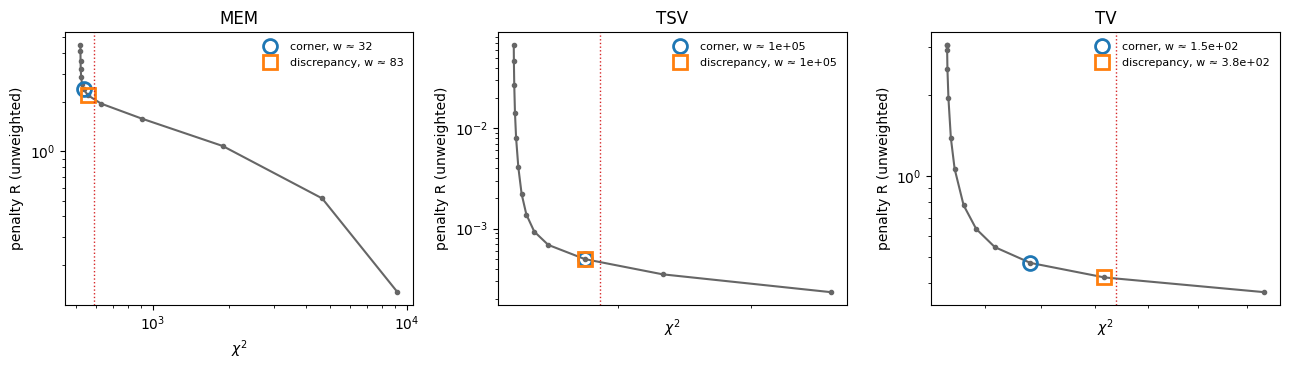

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (name, c) in zip(axes, curves.items()):
    ax.loglog(c.chi2, c.penalty, "-o", ms=3, color="0.4")
    for w, marker, label in [
        (chosen[name][0], "o", "corner"),
        (chosen[name][1], "s", "discrepancy"),
    ]:
        if w is None:
            continue
        i = int(jnp.argmin(jnp.abs(jnp.log(c.weights) - jnp.log(w))))
        ax.loglog(
            c.chi2[i],
            c.penalty[i],
            marker,
            ms=10,
            mfc="none",
            mew=2,
            label=f"{label}, w ≈ {c.weights[i]:.2g}",
        )
    ax.axvline(data.vis.size, color="C3", ls=":", lw=1)
    ax.set(xlabel=r"$\chi^2$", ylabel="penalty R (unweighted)", title=name)
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## The images the criteria select

For each regulariser, the image at its discrepancy weight is shown next to the truth, with its normalised cross-correlation (1 is a perfect match) in the title, and below it the signed difference from the truth on a symmetric scale. The shaded ellipse is the beam. All three recover the ring, its hole and its brighter eastern side. MEM is the most faithful; TSV blurs the ring's edges, and TV, which favours flat regions with sharp edges, makes the bright side blocky.

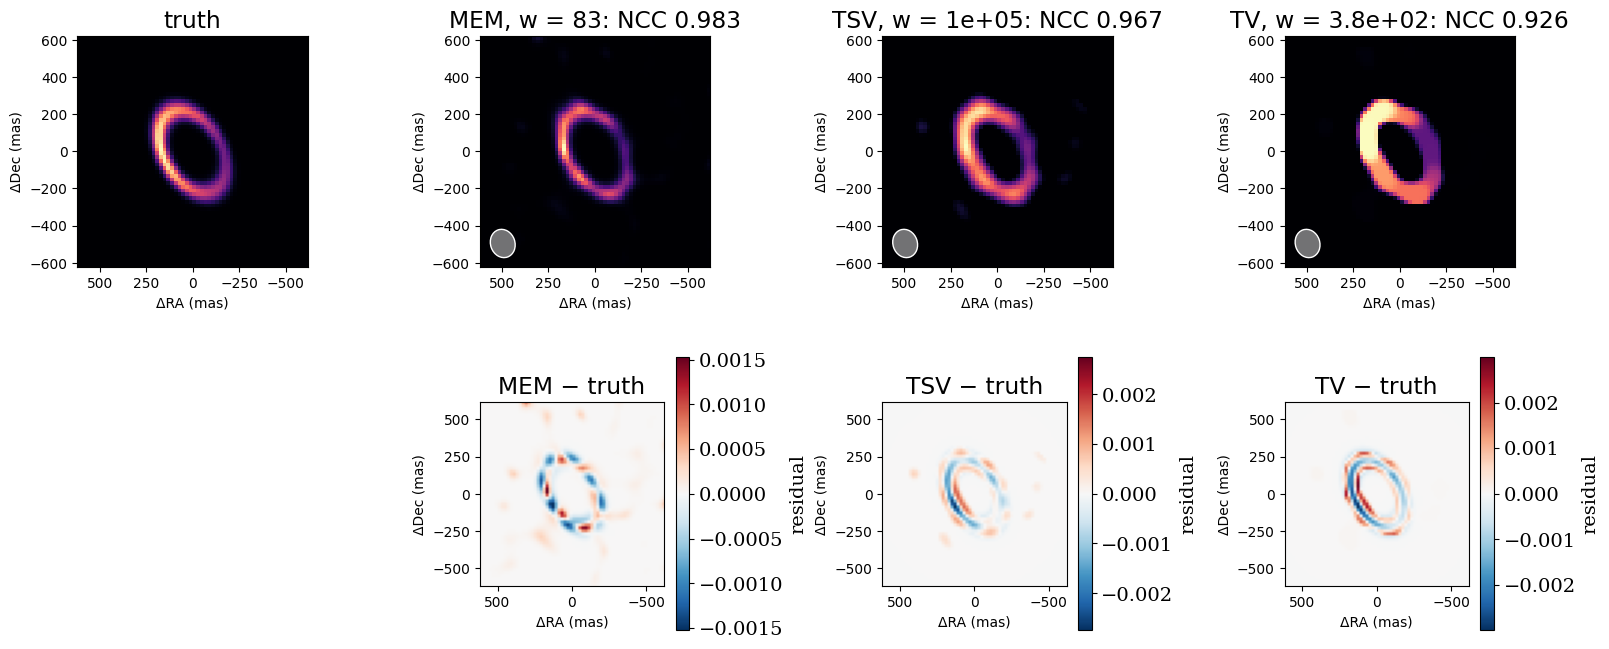

In [4]:
def ncc(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(jnp.sum(a * b) / jnp.sqrt(jnp.sum(a * a) * jnp.sum(b * b)))


fov = npix * scale
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
plot_model(truth.env, fov_mas=fov, npix=npix, ax=axes[0, 0], title="truth")
axes[1, 0].axis("off")
for column, (name, c) in enumerate(curves.items(), start=1):
    w = chosen[name][1] or chosen[name][0]
    i = int(jnp.argmin(jnp.abs(jnp.log(c.weights) - jnp.log(w))))
    image = c.results[i].model.env
    plot_model(
        image,
        fov_mas=fov,
        npix=npix,
        ax=axes[0, column],
        title=f"{name}, w = {c.weights[i]:.2g}: NCC {ncc(image.brightness, truth_image):.3f}",
        beam=beam(data),
    )
    difference = image.render(npix, fov) - truth.env.render(npix, fov)
    plot_residual_map(
        difference, fov_mas=fov, ax=axes[1, column], title=f"{name} − truth"
    )
plt.tight_layout()
plt.show()

## Under- and over-regularisation

The MEM images along its sweep show what the weight does. At strong weights the ring is blurred towards the flat default image and χ² is far too high. Near the discrepancy weight the ring and its hole are sharp and χ² per point reaches one. At the weakest weights the noise takes over: the image breaks up into speckles while χ² hardly improves, because the data no longer constrain those details. The good weights span roughly a decade around the discrepancy weight.

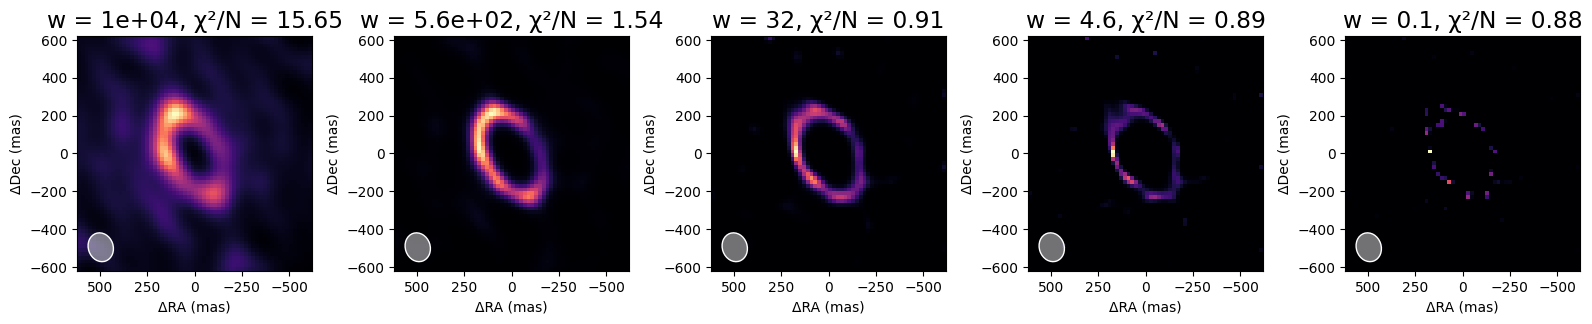

In [5]:
c = curves["MEM"]
picks = [0, 3, 6, 8, 12]
fig, axes = plt.subplots(1, len(picks), figsize=(16, 3.4))
for ax, i in zip(axes, picks):
    image = c.results[i].model.env
    plot_model(
        image,
        fov_mas=fov,
        npix=npix,
        ax=ax,
        title=f"w = {c.weights[i]:.2g}, χ²/N = {c.chi2_red[i, 0]:.2f}",
        beam=beam(data),
    )
plt.tight_layout()
plt.show()

## Summary

`l_curve` sweeps a regulariser's weight with warm starts, and its `corner` and `discrepancy` methods suggest a weight from the same sweep at no extra cost; the discrepancy principle, χ² per point equal to one, is the more reliable of the two here. Plot the curve and look at the images either side of the chosen weight before trusting it; `design/regulariser_weight_selection.md` discusses more sophisticated criteria (cross-validation, generalised cross-validation, Bayesian evidence), which are deferred to the Gaussian-process stage.